### Fluid Mechanics, Sixth Edition | Pijush K. Kundu, Ira M. Cohen, and David R. Dowling | Solutions and Code by David A. Lee
### Chapter 3: Kinematics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\physics")
from plotstyle import C as PAL, FG, BG, savefig, animation_style, saveanim   # this notebook uses C for the contour level

In [2]:
def style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=None, ylim=None,
             xticks=None, xticklabels=None, yticks=None, yticklabels=None,
             color=FG, fontsize=16):
    """Apply shared plot attributes to one or more axes."""
    axes = np.atleast_1d(ax)
    for a in axes:
        a.set_xlabel(xlabel, color=color, fontsize=fontsize)
        a.set_ylabel(ylabel, color=color, fontsize=fontsize)
        a.tick_params(colors=color)
        a.tick_params(labelsize=fontsize)
        a.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
        a.grid(False)
        if xlim is not None:
            a.set_xlim(xlim)
        if ylim is not None:
            a.set_ylim(ylim)
        if xticks is not None:
            a.set_xticks(xticks)
        if xticklabels is not None:
            a.set_xticklabels(xticklabels, color=color)
        if yticks is not None:
            a.set_yticks(yticks)
        if yticklabels is not None:
            a.set_yticklabels(yticklabels, color=color)

Question 3.6

(a)

saved chap3ex3.6a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\physics\fluidmechanics\chap3-code\chap3ex3.6a.pdf


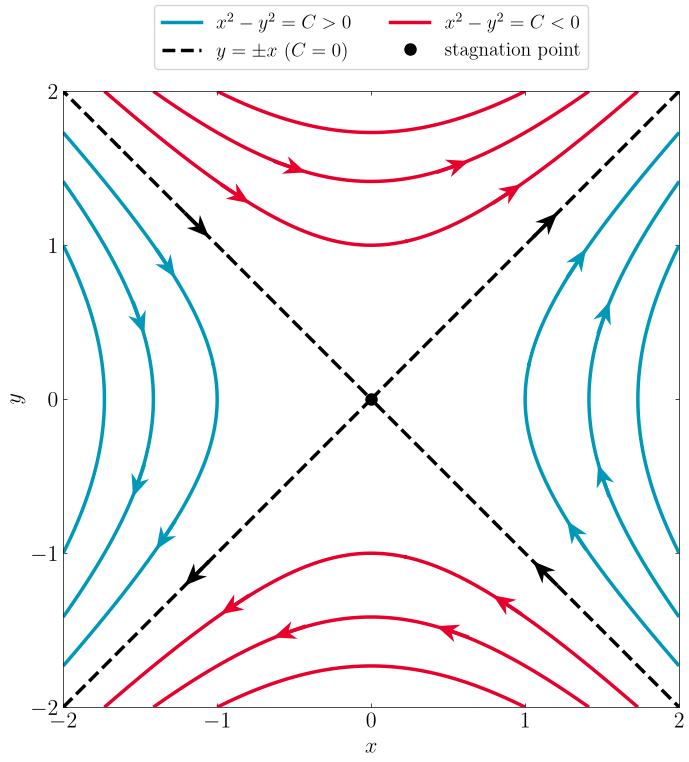

In [3]:
# u = Sy, v = Sx  ->  dy/dx = v/u = x/y  ->  x^2 - y^2 = C  (psi = S(y^2 - x^2)/2)
# S only sets the speed, not the streamline shapes, so take S = 1.
S = 1.0
R = 2.0                      # plot window [-R, R]^2
C_levels = np.arange(-3, 4)  # streamlines x^2 - y^2 = C
colors = {1: PAL.cyan, 0: FG, -1: PAL.red}  # C > 0, C = 0, C < 0

fig, ax = plt.subplots(figsize=(8, 8))

x = np.linspace(-R, R, 801)
X, Y = np.meshgrid(x, x)
for C in C_levels:
    c = colors[int(np.sign(C))]
    ls = '--' if C == 0 else '-'
    ax.contour(X, Y, X**2 - Y**2, levels=[C], colors=c, linewidths=2.5, linestyles=ls)

    # arrows where each streamline crosses the circle x^2 + y^2 = r^2
    r = 1.6
    if abs(C) < r**2:
        xa, ya = np.sqrt((r**2 + C)/2), np.sqrt((r**2 - C)/2)
        px = np.array([xa, xa, -xa, -xa])
        py = np.array([ya, -ya, ya, -ya])
        u, v = S*py, S*px
        speed = np.hypot(u, v)
        ax.quiver(px, py, u/speed, v/speed, color=c, scale=18, width=0.006,
                  headwidth=5, headlength=6, pivot='mid', zorder=3)

ax.plot([], [], color=colors[1], linewidth=2.5, label=r'$x^2 - y^2 = C > 0$')
ax.plot([], [], color=colors[0], linewidth=2.5, linestyle='--', label=r'$y = \pm x$ ($C = 0$)')
ax.plot([], [], color=colors[-1], linewidth=2.5, label=r'$x^2 - y^2 = C < 0$')
ax.plot(0, 0, 'o', color=FG, markersize=8, zorder=4, label='stagnation point')

ticks = [-R, -R/2, 0, R/2, R]
style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=(-R, R), ylim=(-R, R),
         xticks=ticks, yticks=ticks)
ax.set_aspect('equal')
ax.legend(frameon=True, fontsize=14, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)

savefig(fig, "chap3ex3.6a.pdf")
plt.show()

Question 3.10

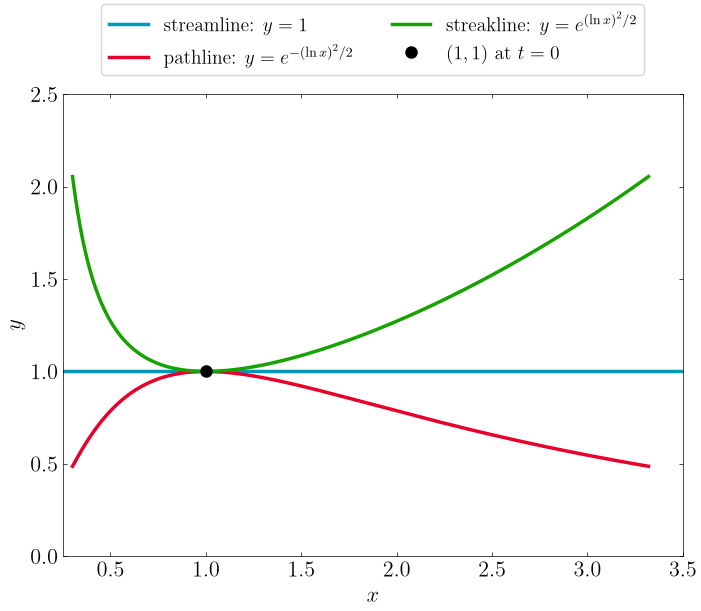

In [4]:
# u = (x, -yt, 0); all three curves pass through (1, 1, 0) at t = 0.
# streamline (t = 0):  dy/dx = v/u = -yt/x = 0      ->  y = 1
# pathline:            dx/dt = x, dy/dt = -yt        ->  x = e^t, y = e^{-t^2/2}
# streakline (t = 0):  particle passing (1,1) at any time tau sits at
#                      x = e^{-tau}, y = e^{tau^2/2}  ->  y = e^{(ln x)^2/2}
T = 1.2
t   = np.linspace(-T, T, 400)   # pathline parameter
tau = np.linspace(-T, T, 400)   # streakline: all particles that ever pass (1,1)

curves = [
    (r'streamline: $y = 1$',                          np.linspace(0.25, 3.5, 2), np.ones(2),          PAL.cyan),
    (r'pathline: $y = e^{-(\ln x)^2/2}$',             np.exp(t),                 np.exp(-t**2/2),     PAL.red),
    (r'streakline: $y = e^{(\ln x)^2/2}$',            np.exp(-tau),              np.exp(tau**2/2),    PAL.green),
]

fig, ax = plt.subplots(figsize=(8, 6))

for label, x, y, c in curves:
    ax.plot(x, y, color=c, linewidth=2.5, label=label)
ax.plot(1, 1, 'o', color=FG, markersize=8, zorder=3, label='$(1, 1)$ at $t = 0$')

style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=(0.25, 3.5), ylim=(0, 2.5),
         xticks=[0.5, 1, 1.5, 2, 2.5, 3, 3.5], yticks=[0, 0.5, 1, 1.5, 2, 2.5])
ax.legend(frameon=True, fontsize=14, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2)

savefig(fig, "chap3ex3.10.pdf", mirror=False)   # not used by the manual
plt.show()

Velocity field snapshots

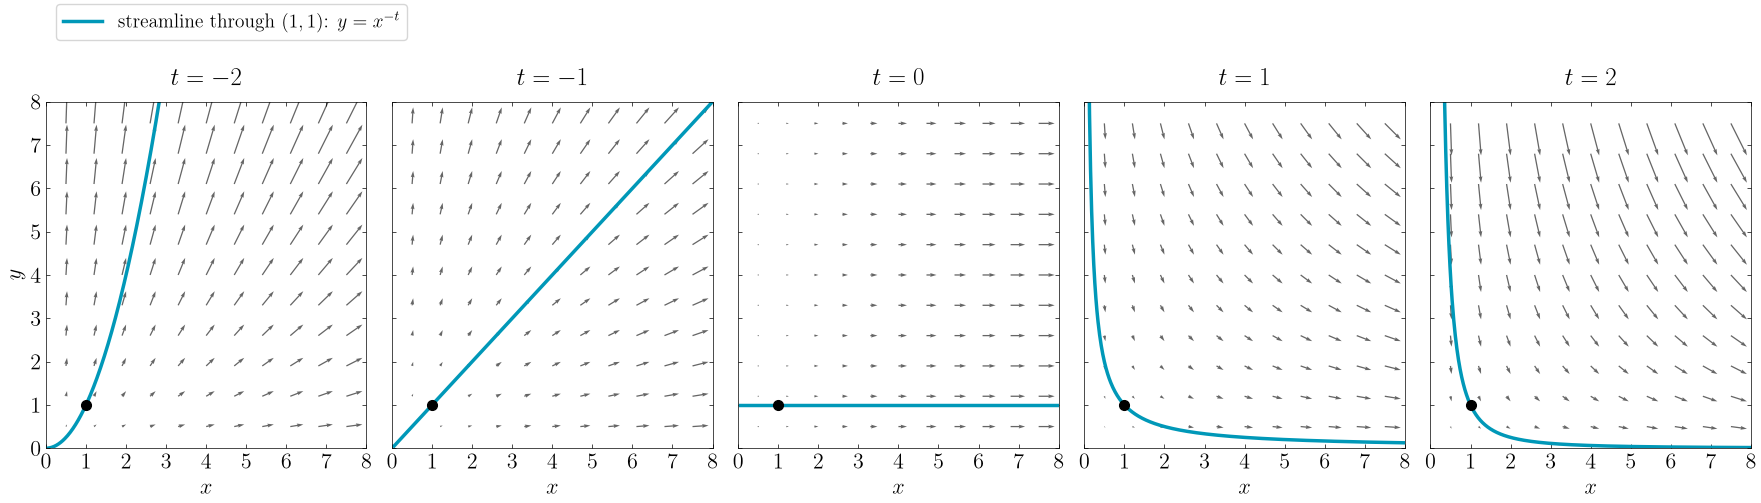

In [5]:
# Snapshots of u = (x, -yt) at several times. The field is unsteady: the vertical
# component flips sign with t, which is why the three curves in 3.10 differ.
# Instantaneous streamline through (1, 1) at time t:  dy/dx = -yt/x  ->  y = x^{-t}
times = [-2, -1, 0, 1, 2]
xg, yg = np.meshgrid(np.linspace(0.5, 7.5, 11), np.linspace(0.5, 7.5, 11))
xs = np.linspace(0.05, 8, 600)

fig, ax = plt.subplots(1, len(times), figsize=(22, 4.5), sharex=True, sharey=True)

for a, t0 in zip(ax, times):
    a.quiver(xg, yg, xg, -yg*t0, color=FG, alpha=0.6, scale=150, width=0.004, zorder=1)
    a.plot(xs, xs**(-t0), color=PAL.cyan, linewidth=2.5, zorder=2)
    a.plot(1, 1, 'o', color=FG, markersize=7, zorder=3)
    a.set_title(f'$t = {t0}$', color=FG, fontsize=18, pad=12)

style_ax(ax, xlabel='$x$', ylabel='', xlim=(0, 8), ylim=(0, 8),
         xticks=range(0, 9), yticks=range(0, 9))
ax[0].set_ylabel('$y$', color=FG, fontsize=16)
ax[0].plot([], [], color=PAL.cyan, linewidth=2.5, label=r'streamline through $(1,1)$: $y = x^{-t}$')
ax[0].legend(frameon=True, fontsize=14, loc='lower left', bbox_to_anchor=(0, 1.15))

fig.subplots_adjust(wspace=0.08)
savefig(fig, "chap3ex3.10-snapshots.pdf", mirror=False)   # not used by the manual
plt.show()

Animation

In [6]:
# Animation of the same field from t = -T to T:
#   quiver      : velocity field u = (x, -yt) at time t
#   streamline  : instantaneous streamline through (1, 1), y = x^{-t}
#   pathline    : trajectory of the particle that is at (1, 1) when t = 0
#   streakline  : locus of every particle that passes (1, 1) at any time tau,
#                 before or after t; that particle is at (e^{t - tau}, e^{-(t^2 - tau^2)/2})
# At t = 0 the three curves are exactly those plotted for 3.10.
from matplotlib.animation import FuncAnimation

T, FPS, N = 2.0, 24, 161
ts = np.linspace(-T, T, N)

with animation_style() as A:                        # black background, neon on black
    fig, ax = plt.subplots(figsize=(8, 6))
    Q = ax.quiver(xg, yg, xg, -yg*ts[0], color=A.FG, alpha=0.5, scale=150, width=0.004, zorder=1)
    stream, = ax.plot([], [], color=A.C.cyan, linewidth=2.5, label=r'streamline: $y = x^{-t}$')
    path,   = ax.plot([], [], color=A.C.red, linewidth=2.5, label='pathline')
    streak, = ax.plot([], [], color=A.C.green, linewidth=2.5, label='streakline')
    dot,    = ax.plot([], [], 'o', color=A.C.red, markeredgecolor=A.FG, markersize=9, zorder=4)
    ax.plot(1, 1, 'o', color=A.FG, markersize=7, zorder=3, label='$(1, 1)$')
    clock = ax.text(0.5, 0.96, '', transform=ax.transAxes, ha='center', va='top', color=A.FG, fontsize=18,
                    bbox=dict(facecolor=A.BG, edgecolor='none', pad=4), zorder=5)

    style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=(0, 8), ylim=(0, 8),
             xticks=range(0, 9), yticks=range(0, 9), color=A.FG)
    ax.legend(frameon=True, fontsize=14, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)

    def update(i):
        t = ts[i]
        Q.set_UVC(xg, -yg*t)
        stream.set_data(xs, xs**(-t))
        tp = ts[:i+1]                                   # pathline: history up to now
        path.set_data(np.exp(tp), np.exp(-tp**2/2))
        dot.set_data([np.exp(t)], [np.exp(-t**2/2)])
        tau = np.linspace(t - 3, t + 6, 600)            # streakline: tau before and after t;
                                                        # window slides so both branches stay in frame
        streak.set_data(np.exp(t - tau), np.exp(-(t**2 - tau**2)/2))
        clock.set_text(f'$t = {t:+.2f}$')
        return Q, stream, path, streak, dot, clock

    ani = FuncAnimation(fig, update, frames=N, blit=False)
    saveanim(ani, "chap3ex3.10.mp4", fps=FPS, dpi=100)   # H.264, crf 18, as before
plt.close(fig)

from IPython.display import Video
Video("chap3ex3.10.mp4", embed=False)

saved chap3ex3.10.mp4 -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\physics\fluidmechanics\chap3-code\chap3ex3.10.mp4
